# 17 · Portfolio construction: from Markowitz to risk parity

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/17_portfolio_construction.ipynb)

How should money be split across assets? This notebook builds the toolkit used at asset managers and pension funds:
expected return and covariance estimation, mean-variance optimisation and the efficient frontier, why optimised
portfolios disappoint (estimation error), covariance shrinkage, risk contributions and risk parity, Black–Litterman,
and an honest walk-forward comparison against the humble 1/N portfolio.

**Data:** 15 years of daily returns for 8 asset classes from a Swiss investor's view (simulated with fat tails,
volatility clusters and a 2020-style crash). Set `USE_REAL_DATA = True` below to run everything on real ETF prices.

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = next((p for p in ["../data/", "../../data/"] if Path(p).exists()), "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/")
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)

# Answer checker: after an exercise, check("01.1") tells you whether your answer is right
import sys
if Path("../checks.py").exists():
    sys.path.insert(0, "..")  # solution notebooks live one folder down
try:
    from checks import check, check_all
except ImportError:  # in Colab: fetch the checker from GitHub
    import urllib.request
    urllib.request.urlretrieve("https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/notebooks/checks.py", "checks.py")
    from checks import check, check_all
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


In [2]:
USE_REAL_DATA = False     # True = download real ETF prices from Yahoo Finance (the exercise checks need False)
ETFS = {"SPY": "US equity", "EFA": "Developed ex-US equity", "EEM": "EM equity", "AGG": "US bonds",
        "TLT": "Long Treasuries", "GLD": "Gold", "VNQ": "Real estate", "DBC": "Commodities"}

def load_returns():
    if USE_REAL_DATA:
        try:
            import subprocess, sys
            try:
                import yfinance as yf
            except ImportError:
                subprocess.run([sys.executable, "-m", "pip", "install", "-q", "yfinance"], check=False)
                import yfinance as yf
            px = yf.download(list(ETFS), start="2010-01-01", end="2024-12-31", auto_adjust=True, progress=False)["Close"]
            r = px.pct_change().dropna(how="all").dropna(axis=1, thresh=1000).dropna()
            if len(r) > 500:
                print("Using real ETF data from Yahoo Finance")
                return r
        except Exception as e:
            print("Download failed:", repr(e)[:150])
        print("Falling back to the bundled dataset")
    return pd.read_csv(DATA + "asset_returns_daily.csv", index_col=0, parse_dates=True)

rets = load_returns()
assets = list(rets.columns); n = len(assets)
print(rets.shape, rets.index[0].date(), "to", rets.index[-1].date())

(3912, 8) 2010-01-04 to 2024-12-31


                   exp. return  volatility  Sharpe
CH_EQUITY                0.097       0.158   0.584
WORLD_EQUITY             0.101       0.165   0.584
EM_EQUITY                0.076       0.212   0.336
CHF_BONDS               -0.008       0.040  -0.332
GLOBAL_BONDS             0.008       0.049   0.070
GOLD                    -0.030       0.146  -0.240
SWISS_REAL_ESTATE        0.096       0.123   0.745
COMMODITIES              0.045       0.201   0.198


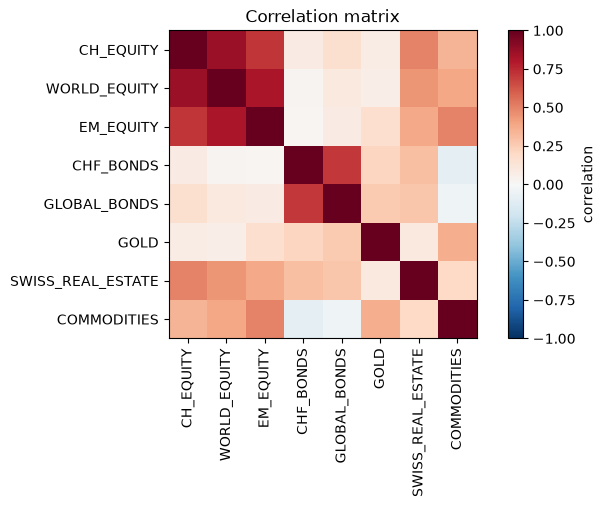

In [3]:
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
ANN = 252
mu = rets.mean() * ANN                       # annual expected returns (sample means)
S = rets.cov() * ANN                         # annual covariance matrix
RF = 0.005                                   # risk-free rate
print(pd.DataFrame({"exp. return": mu, "volatility": np.sqrt(np.diag(S)), "Sharpe": (mu - RF) / np.sqrt(np.diag(S))}).round(3))
plt.imshow(rets.corr(), cmap="RdBu_r", vmin=-1, vmax=1); plt.xticks(range(n), assets, rotation=90); plt.yticks(range(n), assets)
plt.colorbar(label="correlation"); plt.title("Correlation matrix"); plt.show()

## 1. Portfolio return and risk
For weights $w$: expected return $w^\top\mu$, variance $w^\top \Sigma w$, volatility $\sqrt{w^\top \Sigma w}$.
Diversification works because the variance depends on **covariances**, not just on each asset's own risk.

In [4]:
def port_stats(w, mu=mu, S=S):
    w = np.asarray(w); r = w @ mu; v = np.sqrt(w @ S.to_numpy() @ w)
    return r, v, (r - RF) / v
w_ew = np.full(n, 1 / n)
print("Weighted-average asset volatility:", round(float(w_ew @ np.sqrt(np.diag(S))), 4))

Weighted-average asset volatility: 0.1368


### Exercise 1

Compute the annual volatility of the equal-weight (1/N) portfolio, √(wᵀΣw), and store it in `ew_vol`. Compare it with the weighted-average volatility above: that gap is the diversification benefit.

In [5]:
# Your code here

In [6]:
check("17.1");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 17.1: not answered yet. Store your answer in `ew_vol`.


## 2. The global minimum-variance portfolio (closed form)
With only the budget constraint $\sum w = 1$ (short selling allowed), the lowest-risk portfolio is
$$w_{GMV} = \frac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top \Sigma^{-1}\mathbf 1}.$$
It needs **no expected returns**, which is why it is popular in practice.

### Exercise 2

Compute `w_gmv` (an array of 8 weights) with the formula above. Use `np.linalg.solve(S, np.ones(n))` rather than inverting the matrix. Which assets does it short?

In [7]:
# Your code here

In [8]:
check("17.2");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 17.2: not answered yet. Store your answer in `w_gmv`.


## 3. The efficient frontier with real-world constraints
Long-only, fully invested. For each target return, find the minimum-variance portfolio with a numerical optimiser (SLSQP).

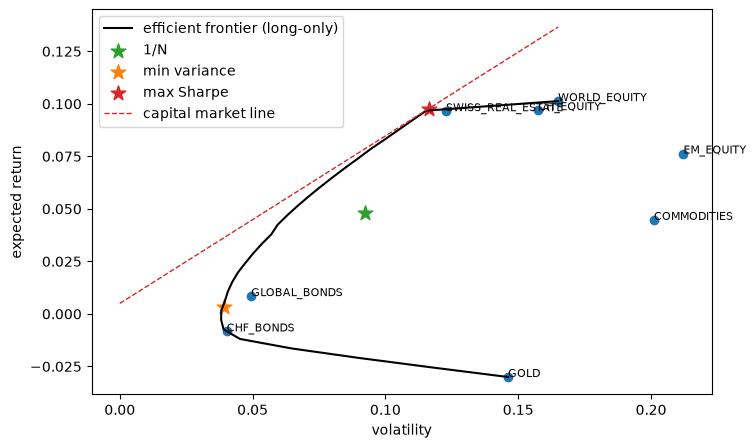

,1/N,min variance,max Sharpe
CH_EQUITY,0.125,0.000,0.030
WORLD_EQUITY,0.125,0.019,0.256
EM_EQUITY,0.125,0.000,0.000
CHF_BONDS,0.125,0.508,0.000
GLOBAL_BONDS,0.125,0.424,0.000
GOLD,0.125,0.000,0.000
SWISS_REAL_ESTATE,0.125,0.000,0.713
COMMODITIES,0.125,0.050,0.000


In [9]:
def optimise(objective, mu=mu, S=S, bounds=(0, 1), extra=()):
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}, *extra]
    res = minimize(objective, np.full(n, 1 / n), method="SLSQP", bounds=[bounds] * n, constraints=cons, options={"maxiter": 500})
    return res.x

Sv = S.to_numpy()
targets = np.linspace(mu.min(), mu.max(), 30)
frontier = []
for t in targets:
    w = optimise(lambda w: w @ Sv @ w, extra=[{"type": "eq", "fun": lambda w, t=t: w @ mu - t}])
    frontier.append(port_stats(w)[:2])
frontier = np.array(frontier)
w_mv = optimise(lambda w: w @ Sv @ w)                                   # long-only minimum variance
w_ms = optimise(lambda w: -(w @ mu - RF) / np.sqrt(w @ Sv @ w))         # long-only maximum Sharpe (tangency)

plt.figure(figsize=(8, 5))
plt.plot(frontier[:, 1], frontier[:, 0], "k-", label="efficient frontier (long-only)")
plt.scatter(np.sqrt(np.diag(Sv)), mu, c="C0"); [plt.annotate(a, (np.sqrt(Sv[i, i]), mu.iloc[i]), fontsize=8) for i, a in enumerate(assets)]
for w, lab, c in [(w_ew, "1/N", "C2"), (w_mv, "min variance", "C1"), (w_ms, "max Sharpe", "C3")]:
    r, v, _ = port_stats(w); plt.scatter(v, r, s=120, c=c, marker="*", label=lab)
r, v, sr = port_stats(w_ms); xs = np.linspace(0, frontier[:, 1].max(), 10); plt.plot(xs, RF + sr * xs, "C3--", lw=1, label="capital market line")
plt.xlabel("volatility"); plt.ylabel("expected return"); plt.legend(); plt.show()
pd.DataFrame({"1/N": w_ew, "min variance": w_mv, "max Sharpe": w_ms}, index=assets).round(3)

## 4. Why optimised portfolios disappoint: estimation error
The optimiser treats your estimates as truth. Expected returns are estimated very imprecisely, so small changes in inputs produce wildly different “optimal” portfolios.

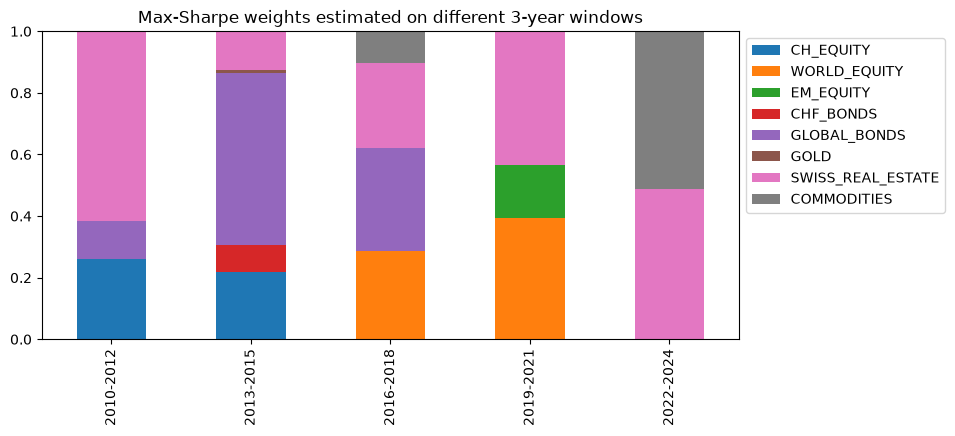

Standard error of each annual mean estimate (15 years of data):
CH_EQUITY            0.040
WORLD_EQUITY         0.042
EM_EQUITY            0.054
CHF_BONDS            0.010
GLOBAL_BONDS         0.013
GOLD                 0.037
SWISS_REAL_ESTATE    0.031
COMMODITIES          0.051
dtype: float64


In [10]:
windows = [("2010", "2012"), ("2013", "2015"), ("2016", "2018"), ("2019", "2021"), ("2022", "2024")]
W = {}
for a, b in windows:
    sub = rets.loc[a:b]; m_, S_ = sub.mean() * ANN, sub.cov().to_numpy() * ANN
    W[f"{a}-{b}"] = optimise(lambda w: -(w @ m_ - RF) / np.sqrt(w @ S_ @ w), mu=m_)
W = pd.DataFrame(W, index=assets)
W.T.plot.bar(stacked=True, figsize=(9, 4), title="Max-Sharpe weights estimated on different 3-year windows"); plt.legend(bbox_to_anchor=(1, 1)); plt.show()
se = rets.std() * np.sqrt(ANN) / np.sqrt(len(rets) / ANN)
print("Standard error of each annual mean estimate (15 years of data):"); print(se.round(3))

The standard error of a 15-year average return is around **4% a year for equities**, as large as the premium you are
trying to estimate. Volatilities and correlations are estimated far more precisely. Hence the practical rules:
prefer methods that need no expected returns (minimum variance, risk parity), shrink inputs, add constraints, or
anchor expected returns to equilibrium (Black–Litterman, Section 7).

## 5. Covariance shrinkage (Ledoit–Wolf)
With short windows or many assets the sample covariance is noisy and nearly singular. Ledoit–Wolf blends it with a simple structured target: $\hat\Sigma = \delta F + (1-\delta) S$, choosing δ optimally from the data.

### Exercise 3

Fit `LedoitWolf()` on the full daily return matrix (`rets.to_numpy()`) and store the estimated shrinkage intensity `.shrinkage_` in `lw_delta`. It will be tiny: with 3,900 days and 8 assets the sample covariance is already precise.

In [11]:
# Your code here

In [12]:
check("17.3");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 17.3: not answered yet. Store your answer in `lw_delta`.


In [13]:
short = rets.iloc[-60:]                                    # only 60 days: a noisy estimate
lw = LedoitWolf().fit(short.to_numpy())
print(f"60-day window: shrinkage δ = {lw.shrinkage_:.3f} | condition number sample {np.linalg.cond(short.cov()):.0f} vs Ledoit-Wolf {np.linalg.cond(lw.covariance_):.0f}")

60-day window: shrinkage δ = 0.109 | condition number sample 228 vs Ledoit-Wolf 32


## 6. Risk contributions and risk parity
Each asset's contribution to portfolio volatility is $RC_i = w_i (\Sigma w)_i / \sigma_p$, and the contributions add
up to $\sigma_p$. Equal *weights* are not equal *risk*.

### Exercise 4

Compute the risk contributions of the 1/N portfolio and store them as **shares of total risk** (an array that sums to 1) in `rc_pct_ew`. How much of the risk comes from the three equity assets?

In [14]:
# Your code here

In [15]:
check("17.4");   # run me after your code: ✅ correct, ❌ try again, ⬜ not answered yet

⬜ Exercise 17.4: not answered yet. Store your answer in `rc_pct_ew`.


In [16]:
def risk_contrib(w, Sv=Sv):
    w = np.asarray(w); sp = np.sqrt(w @ Sv @ w)
    return w * (Sv @ w) / sp

def risk_parity(Sv):
    # equal risk contributions: minimise the dispersion of RC around their mean
    obj = lambda w: ((risk_contrib(w, Sv) - risk_contrib(w, Sv).mean()) ** 2).sum() * 1e4
    res = minimize(obj, np.full(len(Sv), 1 / len(Sv)), method="SLSQP", bounds=[(1e-6, 1)] * len(Sv),
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}], options={"maxiter": 1000, "ftol": 1e-12})
    return res.x

w_rp = risk_parity(Sv)
tab = pd.DataFrame({"1/N weight": w_ew, "1/N risk share": risk_contrib(w_ew) / risk_contrib(w_ew).sum(),
                    "risk-parity weight": w_rp, "risk-parity risk share": risk_contrib(w_rp) / risk_contrib(w_rp).sum()}, index=assets)
print(tab.round(3)); print("vol 1/N:", round(port_stats(w_ew)[1], 4), "| vol risk parity:", round(port_stats(w_rp)[1], 4))

                   1/N weight  1/N risk share  risk-parity weight  \
CH_EQUITY               0.125           0.174               0.062   
WORLD_EQUITY            0.125           0.188               0.060   
EM_EQUITY               0.125           0.247               0.046   
CHF_BONDS               0.125           0.011               0.337   
GLOBAL_BONDS            0.125           0.018               0.249   
GOLD                    0.125           0.083               0.093   
SWISS_REAL_ESTATE       0.125           0.098               0.089   
COMMODITIES             0.125           0.182               0.064   

                   risk-parity risk share  
CH_EQUITY                           0.125  
WORLD_EQUITY                        0.125  
EM_EQUITY                           0.125  
CHF_BONDS                           0.125  
GLOBAL_BONDS                        0.125  
GOLD                                0.125  
SWISS_REAL_ESTATE                   0.125  
COMMODITIES               

## 7. Black–Litterman: start from the market, add your views
Instead of noisy sample means, start from **equilibrium returns** implied by market-cap weights,
$\pi = \delta \Sigma w_{mkt}$, then tilt them toward your views with a confidence:
$$\mu_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\right]$$

In [17]:
w_mkt = pd.Series({"CH_EQUITY": 0.10, "WORLD_EQUITY": 0.30, "EM_EQUITY": 0.05, "CHF_BONDS": 0.20, "GLOBAL_BONDS": 0.20,
                   "GOLD": 0.05, "SWISS_REAL_ESTATE": 0.05, "COMMODITIES": 0.05}).reindex(assets).fillna(1 / n)
w_mkt = w_mkt / w_mkt.sum()
delta, tau = 3.0, 0.05                                     # risk aversion, uncertainty of the prior
pi = delta * Sv @ w_mkt.to_numpy()                          # implied equilibrium excess returns
P = np.zeros((1, n)); P[0, 0], P[0, 1] = 1, -1              # one view: asset 1 beats asset 2 ...
Q = np.array([0.01])                                        # ... by 1% a year
Omega = 4 * np.array([[P[0] @ (tau * Sv) @ P[0]]])          # moderate confidence: view 4x as uncertain as the prior
A = np.linalg.inv(tau * Sv) + P.T @ np.linalg.inv(Omega) @ P
mu_bl = np.linalg.solve(A, np.linalg.inv(tau * Sv) @ pi + P.T @ np.linalg.inv(Omega) @ Q)
w_bl = np.linalg.solve(delta * Sv, mu_bl)                  # optimal weights for the BL expected returns
w_naive = optimise(lambda w: -(w @ mu) / np.sqrt(w @ Sv @ w))  # compare: max Sharpe on raw sample means
print(pd.DataFrame({"market weight": w_mkt, "equilibrium π": pi, "BL expected": mu_bl,
                    "BL weight": w_bl, "change vs market": w_bl - w_mkt.to_numpy(), "sample-mean max Sharpe": w_naive}, index=assets).round(3))
print(f"View: {assets[0]} outperforms {assets[1]} by 1% a year, held with moderate confidence")

                   market weight  equilibrium π  BL expected  BL weight  \
CH_EQUITY                   0.10          0.036        0.037      0.232   
WORLD_EQUITY                0.30          0.040        0.038      0.168   
EM_EQUITY                   0.05          0.046        0.044      0.050   
CHF_BONDS                   0.20          0.002        0.003      0.200   
GLOBAL_BONDS                0.20          0.004        0.004      0.200   
GOLD                        0.05          0.010        0.010      0.050   
SWISS_REAL_ESTATE           0.05          0.018        0.018      0.050   
COMMODITIES                 0.05          0.026        0.025      0.050   

                   change vs market  sample-mean max Sharpe  
CH_EQUITY                     0.132                   0.036  
WORLD_EQUITY                 -0.132                   0.251  
EM_EQUITY                     0.000                   0.000  
CHF_BONDS                     0.000                   0.000  
GLOBAL_BONDS  

Look at the “change vs market” column: Black–Litterman leaves every asset at its market weight **except the two in
your view**, which move in opposite directions. How far they move depends on your confidence (Ω). Compare that with
the sample-mean optimiser in the last column, which bets heavily on whatever happened to do well in the sample.
Try `Q = np.array([0.03])` or drop the factor 4 in Ω (more confidence) and watch the tilt grow. Because the two equity markets are highly correlated, even small views move a lot of weight between them.

## 8. The honest test: walk-forward out-of-sample
Every month, estimate inputs from the previous year only, form each portfolio, and hold it for the next month. Trading costs of 0.10% per unit of turnover.

                            ann. return  ann. vol  Sharpe  max drawdown  \
1/N                               0.051     0.093   0.501        -0.324   
Min variance (sample)            -0.000     0.040  -0.134        -0.259   
Min variance (Ledoit-Wolf)        0.005     0.040  -0.005        -0.240   
Max Sharpe (sample)               0.052     0.109   0.430        -0.336   
Risk parity (Ledoit-Wolf)         0.026     0.058   0.366        -0.262   

                            avg monthly turnover  
1/N                                        0.006  
Min variance (sample)                      0.160  
Min variance (Ledoit-Wolf)                 0.061  
Max Sharpe (sample)                        0.468  
Risk parity (Ledoit-Wolf)                  0.029  


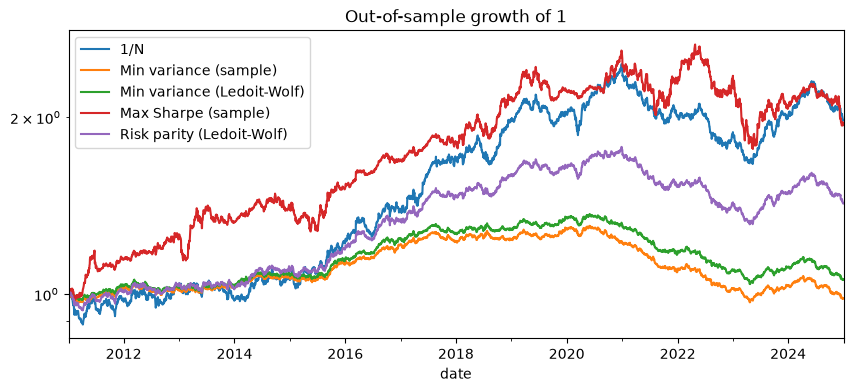

In [18]:
try:
    monthly_ends = rets.resample("ME").last().index
except ValueError:                                         # older pandas
    monthly_ends = rets.resample("M").last().index
COST = 0.001
def backtest(builder, lookback=252):
    out, w_prev, turn = [], np.zeros(n), []
    dates = rets.index
    for i, me in enumerate(monthly_ends[:-1]):
        hist = rets.loc[:me].iloc[-lookback:]
        if len(hist) < lookback:
            continue
        w = builder(hist)
        nxt = rets.loc[(dates > me) & (dates <= monthly_ends[i + 1])]
        r = nxt.to_numpy() @ w
        tc = COST * np.abs(w - w_prev).sum(); turn.append(np.abs(w - w_prev).sum())
        r[0] -= tc
        out.append(pd.Series(r, index=nxt.index)); w_prev = w
    return pd.concat(out), np.mean(turn)

def sample_cov(h): return h.cov().to_numpy() * ANN
def lw_cov(h): return LedoitWolf().fit(h.to_numpy()).covariance_ * ANN
def gmv_long(Sx): return optimise(lambda w: w @ Sx @ w, S=None)
builders = {
    "1/N": lambda h: np.full(n, 1 / n),
    "Min variance (sample)": lambda h: gmv_long(sample_cov(h)),
    "Min variance (Ledoit-Wolf)": lambda h: gmv_long(lw_cov(h)),
    "Max Sharpe (sample)": lambda h: (lambda m_, S_: optimise(lambda w: -(w @ m_ - RF) / np.sqrt(w @ S_ @ w), mu=m_))(h.mean().to_numpy() * ANN, sample_cov(h)),
    "Risk parity (Ledoit-Wolf)": lambda h: risk_parity(lw_cov(h)),
}
results, turns = {}, {}
for name, b in builders.items():
    results[name], turns[name] = backtest(b)
R = pd.DataFrame(results).dropna()

def perf(r):
    g = (1 + r).cumprod(); dd = (g / g.cummax() - 1).min()
    ann_r, ann_v = r.mean() * ANN, r.std() * np.sqrt(ANN)
    return pd.Series({"ann. return": ann_r, "ann. vol": ann_v, "Sharpe": (ann_r - RF) / ann_v, "max drawdown": dd})
summary = R.apply(perf).T; summary["avg monthly turnover"] = pd.Series(turns)
print(summary.round(3))
(1 + R).cumprod().plot(figsize=(10, 4), logy=True, title="Out-of-sample growth of 1"); plt.show()

**What to look for in the table:**
- **Max Sharpe from sample means** trades the most (look at turnover) and, after costs, typically fails to beat 1/N
  on a risk-adjusted basis: its expected-return inputs are mostly noise (the classic DeMiguel–Garlappi–Uppal result).
- **Minimum variance and risk parity** reliably deliver what they promise, much lower volatility, because they only
  need the covariance matrix, which is estimated well. Shrinkage (Ledoit–Wolf) cuts their turnover substantially.
- **Lower risk is not free:** these portfolios hold mostly bonds, so their return is only as good as the bond
  market's. In this sample bonds earned almost nothing, so their Sharpe ratios are low. Investors often lever a
  risk-parity portfolio up to a target volatility for exactly this reason.

**Your turn (no checker):**
1. Add a 40% cap per asset (`bounds=(0, 0.4)`) to the max-Sharpe builder. Does out-of-sample performance improve?
2. Change the lookback from 252 to 756 days (3 years). Which strategies benefit most?
3. Re-run the whole notebook with `USE_REAL_DATA = True`. Do the conclusions hold on real ETFs?

---
## Solutions

In [19]:
ew_vol = float(np.sqrt(w_ew @ Sv @ w_ew)); print("1) 1/N volatility:", round(ew_vol, 4))
x = np.linalg.solve(Sv, np.ones(n)); w_gmv = x / x.sum()
print("2) GMV weights:"); print(pd.Series(w_gmv, index=assets).round(3))
lw_delta = LedoitWolf().fit(rets.to_numpy()).shrinkage_; print("3) shrinkage on full sample:", round(lw_delta, 4))
rc = risk_contrib(w_ew); rc_pct_ew = rc / rc.sum()
print("4) equity share of 1/N risk:", round(rc_pct_ew[:3].sum(), 3))
check_all("17")

1) 1/N volatility: 0.0924
2) GMV weights:
CH_EQUITY           -0.012
WORLD_EQUITY         0.068
EM_EQUITY           -0.030
CHF_BONDS            0.817
GLOBAL_BONDS         0.150
GOLD                -0.018
SWISS_REAL_ESTATE   -0.034
COMMODITIES          0.059
dtype: float64
3) shrinkage on full sample: 0.0031
4) equity share of 1/N risk: 0.608
✅ Exercise 17.1: correct.
✅ Exercise 17.2: correct.
✅ Exercise 17.3: correct.
✅ Exercise 17.4: correct.

4 of 4 exercises correct.
